This notebook produces Figure 2, which is a synthetic example of a cumulative displacement time series with one exceptionally noisy date (e.g., unwrapping error) included, to show that the two methods of inverting for a displacement rate result in very different rates. 
<br>
<br>
Use the "earthscope_insar" conda environment as the Python kernel for this and all subsequent notebooks.
***

In [17]:
# import dependencies
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
%matplotlib  widget

In [18]:
# define some variables to use for synthetic time series. 

# number of SLCs
nd = 11 
# velocity 
V = 5
# sample times
t = np.linspace(0,1,nd+1)
# skip the second regularly-spaced time to show that it works without equal sampling intervals 
t = np.hstack((t[0:3],t[4::])); t=t.T
# true disp time series
true_disp = V*t
# get dt (time intervals of interferograms)
dt = np.diff(t)
# calculate interferogram displacements
true_igram_disps = np.diff(true_disp)
# coherences 
coh = np.ones(nd-1)*0.9
# make this interferogram have low coherence 
coh[6] = 0.15  
# variances (calculated from coherences)
vars = (-2*np.log(coh))  

In [19]:
# set the random seed so it produces the same figure each time.
np.random.seed(2147483648)

# Add random noise to the displacements
igram_disps = true_igram_disps + vars*np.random.randn(nd-1,)

# convert a 2pi unwrapping error into displacement in cm (really an undefined unit in thise figure)
wavelength = 5.5465763   # C-band, in cm 
rad2cm = wavelength/(4*np.pi)   

# add the unwrapping error to the specific interferogram that is noisy
igram_disps[6] = igram_disps[6].copy() - (2*np.pi)*rad2cm
# convert them into the cumulative displacement time series 
cum_igram_disps = np.hstack((0,np.cumsum(igram_disps)))

In [20]:
# for plotting, need a colorscale that represents interferogram coherence 
my_cmap = 'viridis' 
vir2 = cm.get_cmap(my_cmap,1000)
# making the default font size larger for all plots
plt.rcParams.update({'font.size': 14})

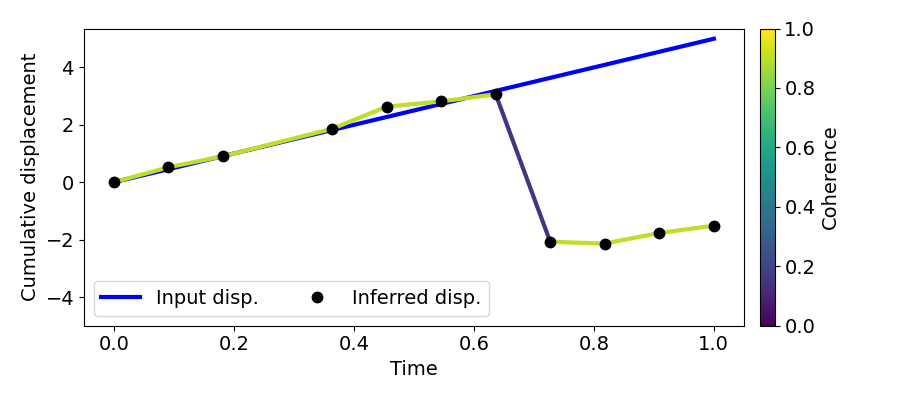

In [21]:
# plot the synthetic dataset without noise (blue) and with noise+unwrapping error (black dots, colored lines according to coherence)
plt.figure(figsize=(9,4),tight_layout='TRUE')
plt.plot(t,true_disp,'b-',linewidth=3,label='Input disp.')
plt.plot(t,cum_igram_disps,'k.',markersize=15,zorder=10,label='Inferred disp.')
for i in range(nd-1):
    plt.plot([t[i],t[i+1]],[cum_igram_disps[i],cum_igram_disps[i+1]],'-',linewidth=3,c=vir2(coh[i]))
norm = mpl.colors.Normalize(vmin=0.0,vmax=1.0)
sm = plt.cm.ScalarMappable(cmap=my_cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=plt.gca(), label='Coherence', pad=0.02)
Ymin,Ymax = plt.ylim(); Xmin,Xmax = plt.xlim()
plt.xlabel('Time'); plt.ylabel('Cumulative displacement')
plt.xlim([Xmin,Xmax]); plt.ylim([Ymin-1,Ymax])
plt.legend(ncol=2,loc='lower left')
plt.ylim(-5,Ymax)
plt.show()

In [22]:
# WEIGHTED INVERSION
# Now make a G and weighting matrix to perform a weighted inversion to estimate the displacement rate.

# weighting matrix:
vars_diag = np.diag(vars,0)
# date-related noise
noise_diags = np.ones(nd-1)             # ones on diagonal 
noise_off_diags = np.ones(nd-2)*(-0.5)  # -0.5 on off diagonals
covi = np.diag(noise_diags,0)+np.diag(noise_off_diags,-1)+np.diag(noise_off_diags,1) 
# add two noise matrices together 
covi2 = vars_diag+covi
# take the inverse
icov = np.linalg.inv(covi2)

# G matrix is from dt, but reshaped
G = (dt.T).reshape(nd-1,1)

# solve for Gg (which is what is multiplied by disps to get rate)
Gg = np.linalg.inv(G.T.dot(icov).dot(G)).dot(G.T).dot(icov)

# solve for rate using weighted inversion of disp rates (which is the d/data matrix)
weighted_vel = Gg.dot(igram_disps)[0]

In [23]:
# UNWEIGHTED INVERSION
# fit a line to the cumulative displacements
cum_disp_vel, cum_disp_intercept = np.polyfit(t,cum_igram_disps,deg=1) 

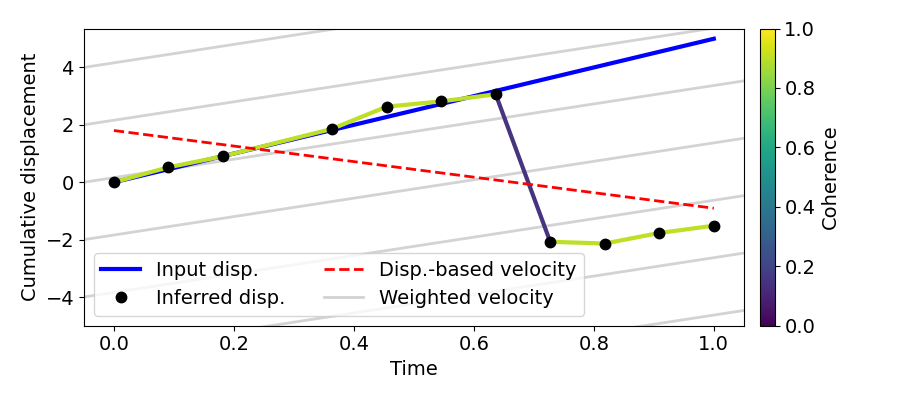

In [24]:
# plot the two methods of inverting: unweighted (red), weighted rate (gray parallel lines because not solving for intercept)
plt.figure(figsize=(9,4),tight_layout='TRUE')
plt.plot(t,true_disp,'b-',linewidth=3,label='Input disp.')
plt.plot(t,cum_igram_disps,'k.',markersize=15,zorder=10,label='Inferred disp.')
for i in range(nd-1):
    plt.plot([t[i],t[i+1]],[cum_igram_disps[i],cum_igram_disps[i+1]],'-',linewidth=3,c=vir2(coh[i]))
norm = mpl.colors.Normalize(vmin=0.0,vmax=1.0)
sm = plt.cm.ScalarMappable(cmap=my_cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=plt.gca(), label='Coherence', pad=0.02)
plt.plot([t[0],t[-1]],[t[0]+cum_disp_intercept,t[-1]*cum_disp_vel+cum_disp_intercept],'r--',linewidth=2,label='Disp.-based velocity')
Ymin,Ymax = plt.ylim(); Xmin,Xmax = plt.xlim()
for u in range(30):
    intercept = -40 + u*2
    x_vals = [Xmin,Xmax]
    y_vals = [(intercept),(intercept+weighted_vel*(Xmax-Xmin))]
    plt.plot(x_vals, y_vals, '-', linewidth=2, c='lightgray',zorder=0)
plt.plot(x_vals, y_vals, '-', linewidth=2, c='lightgray',zorder=0, label='Weighted velocity')
plt.xlabel('Time'); plt.ylabel('Cumulative displacement')
plt.xlim([Xmin,Xmax]); plt.ylim([Ymin-1,Ymax])
plt.legend(ncol=2,loc='lower left')
plt.ylim(-5,Ymax)
#plt.savefig('synth_inversion_example.png',transparent=True,bbox_inches='tight',dpi=500)
plt.show()